In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# %% Setup and config
import glob, math, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
 
torch.manual_seed(0)
device = "cuda"
TRAIN = glob.glob("/kaggle/input/**/train.bin", recursive=True)[0]
VAL = glob.glob("/kaggle/input/**/val.bin", recursive=True)[0]
OUT = "/kaggle/working"
 
# model
VOCAB = 50257
CTX = 256
D = 384
N_LAYER = 6
N_HEAD = 6
FFN_DIM = 1024          # SwiGLU inner width (~8/3 * D)
 
# training
BATCH = 32              # 32 x 256 = 8,192 tokens per step
PEAK_LR = 1e-3
WARMUP = 200
TOTAL_STEPS = 6000      # whole experiment: dense 0-3000, then dense vs MoE 3000-6000
DECAY_START = 4800      # WSD: flat LR, then linear decay over the last 20%
DENSE_STEPS = 3000
EVAL_EVERY = 250
EVAL_BATCHES = 40
 

In [2]:
# %% Data
train_data = np.memmap(TRAIN, dtype=np.uint16, mode="r")
val_data = np.memmap(VAL, dtype=np.uint16, mode="r")
print(f"train {len(train_data):,} tokens | val {len(val_data):,} tokens")
 
 
def get_batch(data, gen=None):
    ix = torch.randint(len(data) - CTX - 1, (BATCH,), generator=gen)
    x = torch.stack([torch.from_numpy(data[i:i + CTX].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i + 1:i + 1 + CTX].astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)
 
 
# fixed val batches: every evaluation (dense, MoE, both branches) sees the exact same tokens
g = torch.Generator().manual_seed(1234)
VAL_BATCHES = [get_batch(val_data, g) for _ in range(EVAL_BATCHES)]

train 30,000,000 tokens | val 1,000,000 tokens


In [3]:
# %% Model
class SwiGLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gate = nn.Linear(D, FFN_DIM, bias=False)
        self.up = nn.Linear(D, FFN_DIM, bias=False)
        self.down = nn.Linear(FFN_DIM, D, bias=False)
 
    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))
 
 
class Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.qkv = nn.Linear(D, 3 * D, bias=False)
        self.proj = nn.Linear(D, D, bias=False)
 
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(D, dim=2)
        q = q.view(B, T, N_HEAD, C // N_HEAD).transpose(1, 2)
        k = k.view(B, T, N_HEAD, C // N_HEAD).transpose(1, 2)
        v = v.view(B, T, N_HEAD, C // N_HEAD).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.proj(y.transpose(1, 2).reshape(B, T, C))
 
 
class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = nn.RMSNorm(D)
        self.attn = Attention()
        self.norm2 = nn.RMSNorm(D)
        self.ffn = SwiGLU()     # Stage 2 swaps this for an MoE layer
 
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x
 
 
class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(VOCAB, D)
        self.pos_emb = nn.Embedding(CTX, D)
        self.blocks = nn.ModuleList([Block() for _ in range(N_LAYER)])
        self.norm = nn.RMSNorm(D)
        self.head = nn.Linear(D, VOCAB, bias=False)
        self.head.weight = self.tok_emb.weight      # tied embeddings
 
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                nn.init.normal_(m.weight, std=0.02)
        for name, p in self.named_parameters():     # smaller init for layers that write into the residual
            if name.endswith("proj.weight") or name.endswith("down.weight"):
                nn.init.normal_(p, std=0.02 / math.sqrt(2 * N_LAYER))
 
    def forward(self, idx, targets):
        T = idx.shape[1]
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.norm(x))
        return F.cross_entropy(logits.view(-1, VOCAB).float(), targets.view(-1))
 
# %% Optimizer, LR schedule, eval, train loop (reused in Stage 3)
def make_optimizer(model):
    decay = [p for p in model.parameters() if p.dim() >= 2]
    no_decay = [p for p in model.parameters() if p.dim() < 2]
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": 0.1}, {"params": no_decay, "weight_decay": 0.0}],
        lr=PEAK_LR, betas=(0.9, 0.95),
    )
 
 
def lr_at(step):
    if step < WARMUP:
        return PEAK_LR * (step + 1) / WARMUP
    if step < DECAY_START:
        return PEAK_LR
    frac = (step - DECAY_START) / (TOTAL_STEPS - DECAY_START)
    return PEAK_LR * (1 - 0.9 * frac)       # ends at 10% of peak
 
 
@torch.no_grad()
def evaluate(model):
    model.eval()
    losses = []
    for x, y in VAL_BATCHES:
        with torch.autocast("cuda", dtype=torch.float16):
            losses.append(model(x, y).item())
    model.train()
    return sum(losses) / len(losses)
 
 
def train(model, opt, scaler, start, end, log, tag):
    t0 = time.time()
    for step in range(start, end):
        for group in opt.param_groups:
            group["lr"] = lr_at(step)
        x, y = get_batch(train_data)
        with torch.autocast("cuda", dtype=torch.float16):
            loss = model(x, y)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()
 
        log["train"].append((step, loss.item()))
        if (step + 1) % EVAL_EVERY == 0 or step + 1 == end:
            v = evaluate(model)
            log["val"].append((step + 1, v))
            print(f"[{tag}] step {step + 1:5d} | train {loss.item():.4f} | val {v:.4f} "
                  f"| lr {lr_at(step):.2e} | {time.time() - t0:.0f}s")

In [4]:
# %% Run Stage 1
model = GPT().to(device)
n_total = sum(p.numel() for p in model.parameters())
n_emb = model.tok_emb.weight.numel() + model.pos_emb.weight.numel()
n_ffn = sum(p.numel() for b in model.blocks for p in b.ffn.parameters())
print(f"params: {n_total / 1e6:.2f}M total | {(n_total - n_emb) / 1e6:.2f}M non-embedding "
      f"| {n_ffn / 1e6:.2f}M in FFNs")
 
opt = make_optimizer(model)
scaler = torch.amp.GradScaler("cuda")
log = {"train": [], "val": [(0, evaluate(model))]}
print(f"val loss at init: {log['val'][0][1]:.4f}  (uniform guess = ln(50257) = {math.log(VOCAB):.4f})")
 
train(model, opt, scaler, 0, DENSE_STEPS, log, "dense")
 
torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
            "scaler": scaler.state_dict(), "step": DENSE_STEPS},
           f"{OUT}/dense_step{DENSE_STEPS}.pt")
json.dump(log, open(f"{OUT}/log_dense.json", "w"))
print("saved checkpoint and log")

params: 30.02M total | 10.62M non-embedding | 7.08M in FFNs
val loss at init: 10.9042  (uniform guess = ln(50257) = 10.8249)
[dense] step   250 | train 3.5067 | val 3.5108 | lr 1.00e-03 | 61s
[dense] step   500 | train 2.9578 | val 2.9050 | lr 1.00e-03 | 122s
[dense] step   750 | train 2.5507 | val 2.6344 | lr 1.00e-03 | 183s
[dense] step  1000 | train 2.3746 | val 2.4927 | lr 1.00e-03 | 243s
[dense] step  1250 | train 2.2739 | val 2.3869 | lr 1.00e-03 | 303s
[dense] step  1500 | train 2.1680 | val 2.3156 | lr 1.00e-03 | 364s
[dense] step  1750 | train 2.1130 | val 2.2704 | lr 1.00e-03 | 424s
[dense] step  2000 | train 2.2200 | val 2.2265 | lr 1.00e-03 | 484s
[dense] step  2250 | train 2.0510 | val 2.1950 | lr 1.00e-03 | 545s
[dense] step  2500 | train 2.1526 | val 2.1636 | lr 1.00e-03 | 605s
[dense] step  2750 | train 2.0146 | val 2.1403 | lr 1.00e-03 | 666s
[dense] step  3000 | train 2.0941 | val 2.1217 | lr 1.00e-03 | 726s
saved checkpoint and log


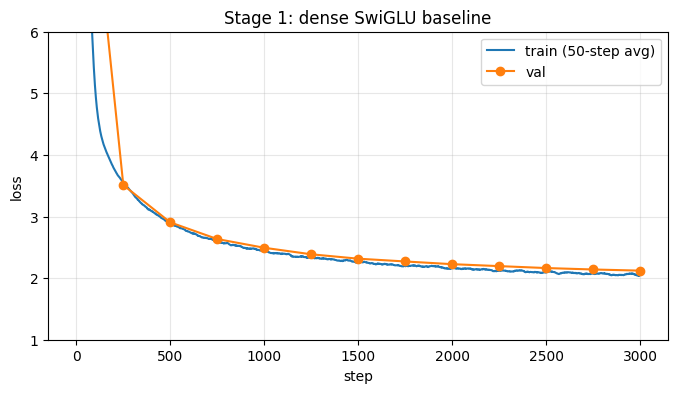

In [5]:
# %% Plot Stage 1
steps, losses = zip(*log["train"])
smooth = np.convolve(losses, np.ones(50) / 50, mode="valid")
vs, vl = zip(*log["val"])
plt.figure(figsize=(8, 4))
plt.plot(steps[49:], smooth, label="train (50-step avg)")
plt.plot(vs, vl, "o-", label="val")
plt.xlabel("step"); plt.ylabel("loss"); plt.ylim(1, 6)
plt.title("Stage 1: dense SwiGLU baseline")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [6]:
# Main notebook — Stage 2: upcycle dense -> MoE and verify equivalence
# Append these cells after Stage 1. No training here; runs in seconds.

# %% MoE config and layer
import copy

N_EXPERTS = 8
TOP_K = 2
AUX_COEF = 0.01         # weight of load-balancing loss (used in Stage 3)


class MoE(nn.Module):
    """Router + N copies of the dense SwiGLU. y = sum over chosen experts of g_i * E_i(x)."""

    def __init__(self, dense_ffn):
        super().__init__()
        self.router = nn.Linear(D, N_EXPERTS, bias=False)
        nn.init.normal_(self.router.weight, std=0.02)
        self.experts = nn.ModuleList([copy.deepcopy(dense_ffn) for _ in range(N_EXPERTS)])
        self.aux_loss = torch.tensor(0.0)
        self.load = None    # share of tokens sent to each expert (ideal = TOP_K / N_EXPERTS = 25%)

    def forward(self, x):
        B, T, C = x.shape
        x = x.reshape(-1, C)
        probs = F.softmax(self.router(x).float(), dim=-1)           # (tokens, experts)
        top_w, top_i = probs.topk(TOP_K, dim=-1)                    # (tokens, k)
        top_w = top_w / top_w.sum(dim=-1, keepdim=True)             # chosen weights sum to 1

        out = torch.zeros_like(x)
        for e, expert in enumerate(self.experts):
            tok, slot = (top_i == e).nonzero(as_tuple=True)         # tokens that picked expert e
            if tok.numel() == 0:
                continue
            y = expert(x[tok]) * top_w[tok, slot, None]
            out.index_add_(0, tok, y.to(out.dtype))

        # Switch-style load balancing: N * sum_e (fraction routed to e) * (mean router prob of e)
        counts = F.one_hot(top_i, N_EXPERTS).sum(dim=1).float()     # (tokens, experts), 0/1
        self.load = counts.mean(dim=0).detach()
        self.aux_loss = N_EXPERTS * ((counts.mean(dim=0) / TOP_K) * probs.mean(dim=0)).sum()
        return out.view(B, T, C)


def upcycle(dense_model, seed=42):
    torch.manual_seed(seed)                     # fixed router init
    moe_model = copy.deepcopy(dense_model)
    for block in moe_model.blocks:
        block.ffn = MoE(block.ffn)
    return moe_model.to(device)


def aux_total(model):
    return sum(b.ffn.aux_loss for b in model.blocks)

In [7]:
# %% Load the dense checkpoint and convert
ckpt = torch.load(f"{OUT}/dense_step{DENSE_STEPS}.pt", map_location=device)
dense = GPT().to(device)
dense.load_state_dict(ckpt["model"])
moe = upcycle(dense)

n_dense = sum(p.numel() for p in dense.parameters())
n_moe = sum(p.numel() for p in moe.parameters())
n_expert = sum(p.numel() for p in moe.blocks[0].ffn.experts[0].parameters())
n_active = n_moe - N_LAYER * (N_EXPERTS - TOP_K) * n_expert
print(f"dense: {n_dense / 1e6:.2f}M params")
print(f"MoE:   {n_moe / 1e6:.2f}M total | {n_active / 1e6:.2f}M active per token "
      f"({N_EXPERTS} experts, top-{TOP_K})")


dense: 30.02M params
MoE:   79.58M total | 37.12M active per token (8 experts, top-2)


In [8]:
# %% Check 1: each MoE layer reproduces its dense FFN (fp32, no autocast)
with torch.no_grad():
    h = torch.randn(4, CTX, D, device=device)
    for i in range(N_LAYER):
        diff = (dense.blocks[i].ffn(h) - moe.blocks[i].ffn(h)).abs().max().item()
        print(f"layer {i}: max |dense - MoE| = {diff:.2e}")

layer 0: max |dense - MoE| = 5.72e-06
layer 1: max |dense - MoE| = 4.05e-06
layer 2: max |dense - MoE| = 3.10e-06
layer 3: max |dense - MoE| = 3.16e-06
layer 4: max |dense - MoE| = 4.77e-06
layer 5: max |dense - MoE| = 5.72e-06


In [9]:
# %% Check 2: same val loss on the fixed val batches
v_dense = evaluate(dense)
v_moe = evaluate(moe)
print(f"val loss dense: {v_dense:.5f}")
print(f"val loss MoE:   {v_moe:.5f}")
print(f"difference:     {abs(v_dense - v_moe):.2e}")

val loss dense: 2.12171
val loss MoE:   2.12171
difference:     1.74e-06


In [10]:
# %% Check 3: router gets zero gradient from the main loss, nonzero from the aux loss
x, y = VAL_BATCHES[0]
routers = [b.ffn.router.weight for b in moe.blocks]

moe.zero_grad()
moe(x, y).backward()
g_main = sum(r.grad.norm().item() for r in routers)

moe.zero_grad()
moe(x, y)
aux_total(moe).backward()
g_aux = sum(r.grad.norm().item() for r in routers)
moe.zero_grad()

print(f"router grad norm from main loss: {g_main:.2e}   (expected ~0: identical experts)")
print(f"router grad norm from aux loss:  {g_aux:.2e}   (expected > 0)")

router grad norm from main loss: 6.00e-08   (expected ~0: identical experts)
router grad norm from aux loss:  5.64e+00   (expected > 0)


In [11]:
# %% Initial routing (random router) on one val batch
with torch.no_grad():
    moe(x, y)
for i, b in enumerate(moe.blocks):
    print(f"layer {i} load %: " + " ".join(f"{100 * l:5.1f}" for l in b.ffn.load.tolist()))
print(f"ideal: {100 * TOP_K / N_EXPERTS:.1f}% each")

torch.save({"model": moe.state_dict(), "step": DENSE_STEPS}, f"{OUT}/moe_step{DENSE_STEPS}.pt")
print("saved upcycled MoE checkpoint")

layer 0 load %:  26.4  13.3  15.6  17.9  21.7  48.0   8.9  48.1
layer 1 load %:  20.4  14.7  10.9  47.4  27.0  48.2  20.9  10.5
layer 2 load %:   8.6  18.8  31.7  37.2  10.1  29.4   9.7  54.5
layer 3 load %:  10.9  34.2  15.1  20.8  38.2  12.5  29.0  39.3
layer 4 load %:  21.4  32.3  32.2  28.6  15.5  16.6  25.7  27.7
layer 5 load %:  20.9  19.3  41.3   9.3  39.1  18.9  27.7  23.4
ideal: 25.0% each
saved upcycled MoE checkpoint


In [12]:
# %% Stage 3 helpers
import re
 
 
def load_dense():
    ckpt = torch.load(f"{OUT}/dense_step{DENSE_STEPS}.pt", map_location=device)
    m = GPT().to(device)
    m.load_state_dict(ckpt["model"])
    opt = make_optimizer(m)
    opt.load_state_dict(ckpt["opt"])
    scaler = torch.amp.GradScaler("cuda")
    scaler.load_state_dict(ckpt["scaler"])
    return m, opt, scaler
 
 
def moe_optimizer_from_dense(moe_model, dense_model, dense_opt):
    """Option A: every expert copies its dense FFN's Adam state; the router starts fresh."""
    opt = make_optimizer(moe_model)
    dense_params = dict(dense_model.named_parameters())
    copied, fresh = 0, 0
    for name, p in moe_model.named_parameters():
        if "router" in name:
            fresh += 1
            continue
        dense_name = re.sub(r"ffn\.experts\.\d+\.", "ffn.", name)   # blocks.0.ffn.experts.3.up -> blocks.0.ffn.up
        opt.state[p] = {k: v.clone() for k, v in dense_opt.state[dense_params[dense_name]].items()}
        copied += 1
    print(f"optimizer state: copied for {copied} tensors, fresh for {fresh} router tensors")
    return opt
 
 
@torch.no_grad()
def moe_stats(model, n_batches=5):
    """Per-layer load (share of tokens per expert) and expert spread (how far experts have drifted apart)."""
    model.eval()
    loads = torch.zeros(N_LAYER, N_EXPERTS, device=device)
    for x, y in VAL_BATCHES[:n_batches]:
        with torch.autocast("cuda", dtype=torch.float16):
            model(x, y)
        loads += torch.stack([b.ffn.load for b in model.blocks])
    model.train()
 
    spread = []
    for b in model.blocks:
        W = torch.stack([torch.cat([p.flatten() for p in e.parameters()]) for e in b.ffn.experts])
        mean = W.mean(dim=0)
        spread.append(((W - mean).norm(dim=1).mean() / mean.norm()).item())   # 0 = identical copies
    return (loads / n_batches).tolist(), spread
 
 
def train_branch(model, opt, scaler, start, end, tag, aux_coef=0.0, seed=7):
    is_moe = aux_coef > 0
    torch.manual_seed(seed)                     # both branches draw the same training batches
    log = {"train": [], "val": [(start, evaluate(model))], "aux": [], "load": [], "spread": []}
    if is_moe:
        load, spread = moe_stats(model)
        log["load"].append((start, load))
        log["spread"].append((start, spread))
    print(f"[{tag}] step {start:5d} | val {log['val'][0][1]:.4f}  (handoff)")
 
    t0 = time.time()
    for step in range(start, end):
        for group in opt.param_groups:
            group["lr"] = lr_at(step)
        x, y = get_batch(train_data)
        with torch.autocast("cuda", dtype=torch.float16):
            loss = model(x, y)
            total = loss + aux_coef * aux_total(model) if is_moe else loss
        opt.zero_grad(set_to_none=True)
        scaler.scale(total).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()
 
        log["train"].append((step, loss.item()))              # main loss only, comparable across branches
        if is_moe:
            log["aux"].append((step, aux_total(model).item() / N_LAYER))   # 1.0 = perfectly balanced
 
        if (step + 1) % EVAL_EVERY == 0 or step + 1 == end:
            v = evaluate(model)
            log["val"].append((step + 1, v))
            msg = (f"[{tag}] step {step + 1:5d} | train {loss.item():.4f} | val {v:.4f} "
                   f"| lr {lr_at(step):.2e} | {time.time() - t0:.0f}s")
            if is_moe:
                load, spread = moe_stats(model)
                log["load"].append((step + 1, load))
                log["spread"].append((step + 1, spread))
                msg += (f" | aux {log['aux'][-1][1]:.3f} | max load {100 * max(max(l) for l in load):.0f}%"
                        f" | spread {np.mean(spread):.3f}")
            print(msg)
    return log

In [13]:
# %% Branch (a): MoE
dense0, dense_opt, dense_scaler = load_dense()
moe = upcycle(dense0)                                   # same seed as Stage 2 -> same router init
moe_opt = moe_optimizer_from_dense(moe, dense0, dense_opt)
del dense0, dense_opt
 
log_moe = train_branch(moe, moe_opt, dense_scaler, DENSE_STEPS, TOTAL_STEPS, "moe", aux_coef=AUX_COEF)
json.dump(log_moe, open(f"{OUT}/log_moe.json", "w"))
torch.save({"model": moe.state_dict(), "step": TOTAL_STEPS}, f"{OUT}/moe_step{TOTAL_STEPS}.pt")
del moe, moe_opt
torch.cuda.empty_cache()

optimizer state: copied for 171 tensors, fresh for 6 router tensors
[moe] step  3000 | val 2.1217  (handoff)
[moe] step  3250 | train 2.0738 | val 2.1325 | lr 1.00e-03 | 84s | aux 1.006 | max load 39% | spread 0.225
[moe] step  3500 | train 1.9653 | val 2.1145 | lr 1.00e-03 | 168s | aux 1.010 | max load 48% | spread 0.323
[moe] step  3750 | train 1.9908 | val 2.1017 | lr 1.00e-03 | 252s | aux 1.011 | max load 50% | spread 0.392
[moe] step  4000 | train 2.0208 | val 2.0821 | lr 1.00e-03 | 336s | aux 1.009 | max load 50% | spread 0.449
[moe] step  4250 | train 1.9752 | val 2.0666 | lr 1.00e-03 | 420s | aux 1.013 | max load 50% | spread 0.498
[moe] step  4500 | train 1.9607 | val 2.0512 | lr 1.00e-03 | 504s | aux 1.011 | max load 51% | spread 0.542
[moe] step  4750 | train 1.9703 | val 2.0443 | lr 1.00e-03 | 588s | aux 1.012 | max load 52% | spread 0.582
[moe] step  5000 | train 1.9594 | val 2.0047 | lr 8.51e-04 | 672s | aux 1.009 | max load 51% | spread 0.614
[moe] step  5250 | train 1.9

In [14]:
# %% Branch (b): dense control
dense, opt, scaler = load_dense()
log_dc = train_branch(dense, opt, scaler, DENSE_STEPS, TOTAL_STEPS, "dense")
json.dump(log_dc, open(f"{OUT}/log_dense_cont.json", "w"))
del dense, opt
torch.cuda.empty_cache()

[dense] step  3000 | val 2.1217  (handoff)
[dense] step  3250 | train 2.0492 | val 2.1076 | lr 1.00e-03 | 61s
[dense] step  3500 | train 1.9408 | val 2.0892 | lr 1.00e-03 | 121s
[dense] step  3750 | train 1.9706 | val 2.0799 | lr 1.00e-03 | 182s
[dense] step  4000 | train 2.0145 | val 2.0626 | lr 1.00e-03 | 242s
[dense] step  4250 | train 1.9528 | val 2.0525 | lr 1.00e-03 | 303s
[dense] step  4500 | train 1.9489 | val 2.0388 | lr 1.00e-03 | 363s
[dense] step  4750 | train 1.9711 | val 2.0346 | lr 1.00e-03 | 424s
[dense] step  5000 | train 1.9450 | val 2.0015 | lr 8.51e-04 | 485s
[dense] step  5250 | train 1.9465 | val 1.9635 | lr 6.63e-04 | 545s
[dense] step  5500 | train 1.8049 | val 1.9273 | lr 4.76e-04 | 606s
[dense] step  5750 | train 1.7928 | val 1.8894 | lr 2.88e-04 | 666s
[dense] step  6000 | train 1.6856 | val 1.8592 | lr 1.01e-04 | 727s


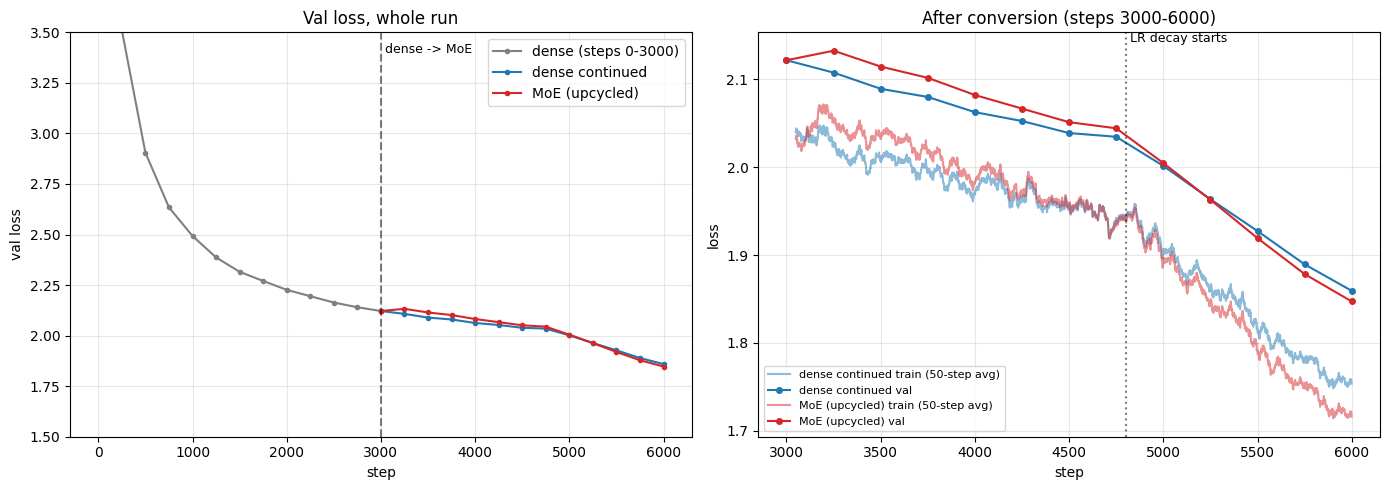

                           dense       MoE
val @ handoff (3000)      2.1217    2.1217
val @ end (6000)          1.8592    1.8471
drop after handoff        0.2625    0.2746


In [15]:
# %% Results: loss plot + table
log_d1 = json.load(open(f"{OUT}/log_dense.json"))
 
 
def smoothed(log, k=50):
    s, l = zip(*log["train"])
    return s[k - 1:], np.convolve(l, np.ones(k) / k, mode="valid")
 
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
# left: whole run, val loss
for lg, name, c in [(log_d1, "dense (steps 0-3000)", "gray"),
                    (log_dc, "dense continued", "C0"),
                    (log_moe, "MoE (upcycled)", "C3")]:
    vs, vl = zip(*lg["val"])
    ax1.plot(vs, vl, "o-", ms=3, color=c, label=name)
ax1.axvline(DENSE_STEPS, ls="--", color="k", alpha=0.5)
ax1.text(DENSE_STEPS, 3.4, " dense -> MoE", fontsize=9)
ax1.set_ylim(1.5, 3.5); ax1.set_xlabel("step"); ax1.set_ylabel("val loss")
ax1.set_title("Val loss, whole run"); ax1.legend(); ax1.grid(alpha=0.3)
 
# right: after the handoff, train (smoothed) + val
for lg, name, c in [(log_dc, "dense continued", "C0"), (log_moe, "MoE (upcycled)", "C3")]:
    s, l = smoothed(lg)
    ax2.plot(s, l, color=c, alpha=0.5, label=f"{name} train (50-step avg)")
    vs, vl = zip(*lg["val"])
    ax2.plot(vs, vl, "o-", ms=4, color=c, label=f"{name} val")
ax2.axvline(DECAY_START, ls=":", color="k", alpha=0.5)
ax2.text(DECAY_START, ax2.get_ylim()[1], " LR decay starts", fontsize=9, va="top")
ax2.set_xlabel("step"); ax2.set_ylabel("loss")
ax2.set_title("After conversion (steps 3000-6000)"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT}/loss_curves.png", dpi=120); plt.show()
 
d0, d1 = log_dc["val"][0][1], log_dc["val"][-1][1]
m0, m1 = log_moe["val"][0][1], log_moe["val"][-1][1]
print(f"{'':22s}{'dense':>10s}{'MoE':>10s}")
print(f"{'val @ handoff (3000)':22s}{d0:10.4f}{m0:10.4f}")
print(f"{'val @ end (6000)':22s}{d1:10.4f}{m1:10.4f}")
print(f"{'drop after handoff':22s}{d0 - d1:10.4f}{m0 - m1:10.4f}")

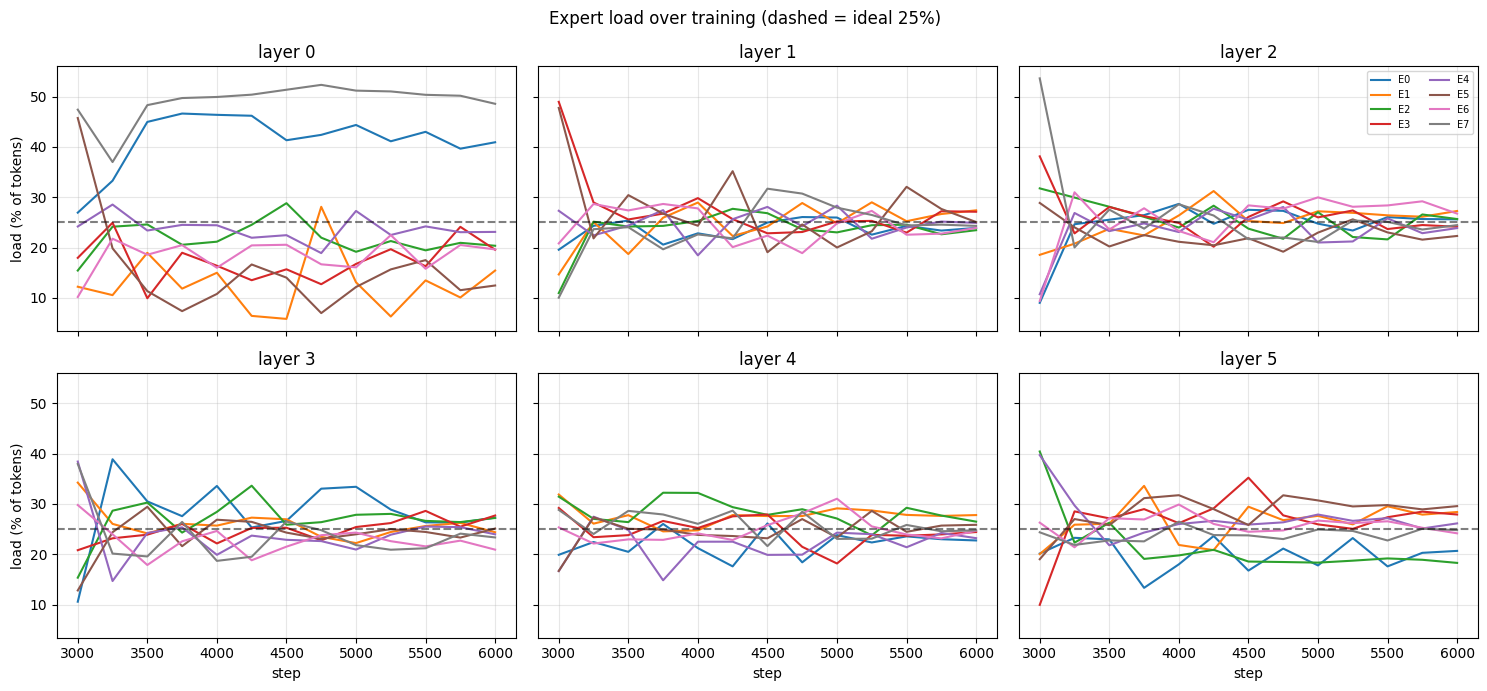

In [16]:
 # %% Load logs
log_moe = json.load(open(f"{OUT}/log_moe.json"))
steps = np.array([s for s, _ in log_moe["load"]])
load = 100 * np.array([l for _, l in log_moe["load"]])     # (evals, layers, experts), in %
spread = np.array([s for _, s in log_moe["spread"]])        # (evals, layers)
ideal = 100 * TOP_K / N_EXPERTS
 
# %% Plot 1: load of every expert over time, one panel per layer
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    for e in range(N_EXPERTS):
        ax.plot(steps, load[:, i, e], label=f"E{e}")
    ax.axhline(ideal, ls="--", color="k", alpha=0.5)
    ax.set_title(f"layer {i}")
    ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("step")
for ax in axes[:, 0]:
    ax.set_ylabel("load (% of tokens)")
axes[0, 2].legend(fontsize=7, ncol=2)
fig.suptitle(f"Expert load over training (dashed = ideal {ideal:.0f}%)")
plt.tight_layout(); plt.savefig(f"{OUT}/expert_load.png", dpi=120); plt.show()

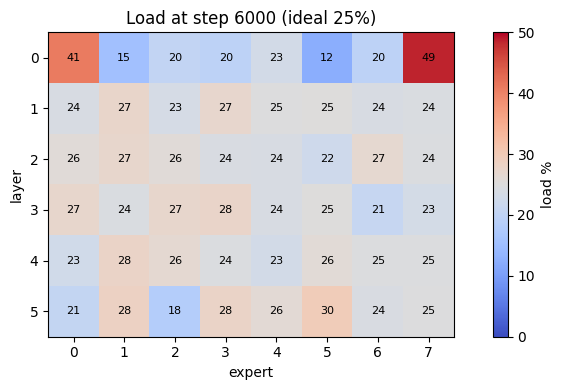

In [17]:
# %% Plot 2: final load heatmap (layer x expert)
plt.figure(figsize=(8, 4))
plt.imshow(load[-1], cmap="coolwarm", vmin=0, vmax=2 * ideal)
for i in range(N_LAYER):
    for e in range(N_EXPERTS):
        plt.text(e, i, f"{load[-1, i, e]:.0f}", ha="center", va="center", fontsize=8)
plt.colorbar(label="load %")
plt.xlabel("expert"); plt.ylabel("layer")
plt.title(f"Load at step {steps[-1]} (ideal {ideal:.0f}%)")
plt.tight_layout(); plt.savefig(f"{OUT}/load_heatmap.png", dpi=120); plt.show()

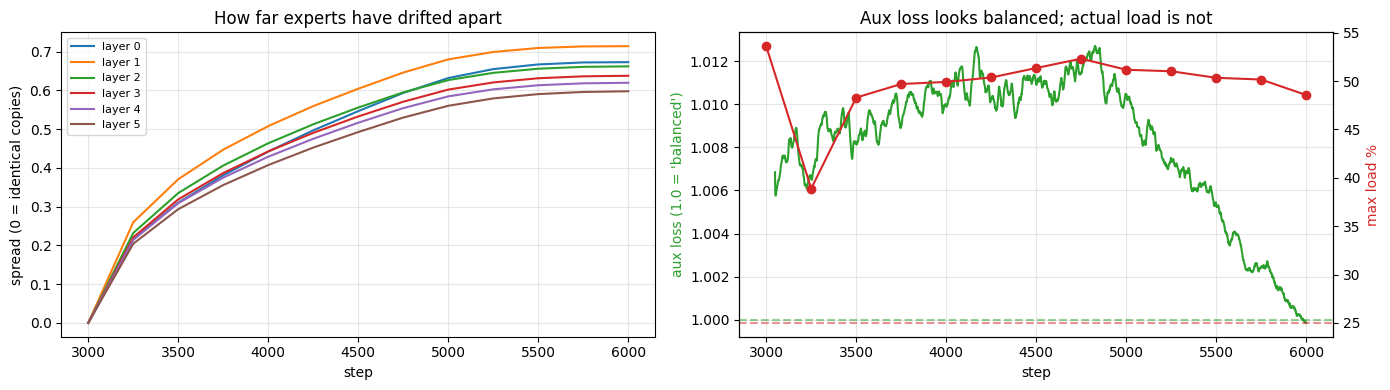

In [18]:
# %% Plot 3: expert spread per layer, and aux loss vs actual max load
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
 
for i in range(N_LAYER):
    ax1.plot(steps, spread[:, i], label=f"layer {i}")
ax1.set_xlabel("step"); ax1.set_ylabel("spread (0 = identical copies)")
ax1.set_title("How far experts have drifted apart"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
 
a_steps, a_vals = zip(*log_moe["aux"])
a_smooth = np.convolve(a_vals, np.ones(50) / 50, mode="valid")
ax2.plot(a_steps[49:], a_smooth, color="C2", label="aux loss per layer (50-step avg)")
ax2.axhline(1.0, ls="--", color="C2", alpha=0.5)
ax2.set_ylabel("aux loss (1.0 = 'balanced')", color="C2")
ax2b = ax2.twinx()
ax2b.plot(steps, load.max(axis=(1, 2)), "o-", color="C3", label="max load (any layer)")
ax2b.axhline(ideal, ls="--", color="C3", alpha=0.5)
ax2b.set_ylabel("max load %", color="C3")
ax2.set_xlabel("step"); ax2.set_title("Aux loss looks balanced; actual load is not")
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT}/spread_aux.png", dpi=120); plt.show()

In [19]:
# %% Table: final load per layer
print(f"load at step {steps[-1]} (ideal {ideal:.0f}%)")
print(f"{'layer':>5} {'max %':>7} {'min %':>7} {'max/ideal':>10} {'experts <10%':>13} {'spread':>7}")
for i in range(N_LAYER):
    l = load[-1, i]
    print(f"{i:5d} {l.max():7.1f} {l.min():7.1f} {l.max() / ideal:10.2f} {(l < 10).sum():13d} {spread[-1, i]:7.3f}")

load at step 6000 (ideal 25%)
layer   max %   min %  max/ideal  experts <10%  spread
    0    48.6    12.5       1.94             0   0.673
    1    27.4    23.4       1.10             0   0.714
    2    27.3    22.3       1.09             0   0.662
    3    27.7    20.9       1.11             0   0.638
    4    27.8    22.8       1.11             0   0.620
    5    29.6    18.3       1.18             0   0.598
